# Time Series Causal Discovery with PCMCI

**Chapter 15: Causal Machine Learning**
**Docker image**: `ml4t`
**Section Reference**: See Section 15.6 for PCMCI theory and ADIA Lab insights

## Purpose
This notebook demonstrates **causal discovery** - learning the causal structure
from time series data without specifying a DAG a priori. We compare PCMCI with
traditional Granger causality and show how to discover lead-lag relationships
in multi-asset financial time series.

## Learning Objectives
After completing this notebook, you will be able to:
- LO1: Apply PCMCI algorithm for time series causal discovery
- LO2: Compare Granger causality limitations with PCMCI advantages
- LO3: Interpret discovered causal graphs with time lags
- LO4: Assess edge stability via bootstrap analysis

## Methodology Reference
Runge et al. (2019) "Detecting and quantifying causal associations in large
nonlinear time series datasets" Science Advances

## Key Concepts
1. **Causal discovery**: Infer DAG from data (vs specifying it)
2. **PCMCI algorithm**: PC skeleton + Momentary Conditional Independence
3. **Time lags**: Causal relationships can have delays
4. **Stability analysis**: Bootstrap to assess edge reliability

**Prerequisites**: [`01_library_overview`](01_library_overview.ipynb) for library context;
ETF OHLCV data from Ch2 data pipeline

## Important Methodological Notes

### Multiple Testing Correction

PCMCI separates two statistical decisions. `pc_alpha` regularizes parent
selection in PC1; it is not a multiple-testing correction for the final MCI
tests. This notebook lets Tigramite select `pc_alpha` and applies its explicit
Benjamini-Hochberg false-discovery-rate correction to the MCI p-values.

### Lag Selection

`MAX_LAG` defines which delayed causal effects can be discovered. We predeclare
a five-trading-day horizon based on the weekly financial response window. The
ACF is descriptive evidence about serial dependence, not a rule for excluding
cross-variable causal delays.

## Setup

In [1]:
"""Time Series Causal Discovery with PCMCI - discover lead-lag causal relationships in financial time series."""

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from data import load_etfs, load_macro
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, apply_ml4t_style, show_with_alt

In [2]:
MAX_LAG = 5
ALPHA_LEVEL = 0.05
N_BOOTSTRAP = 100
N_SAMPLES = 500
SEED = 42
BLOCK_SIZE = 20  # Block size for bootstrap (preserves autocorrelation)
STABILITY_THRESHOLD = 0.5  # Edge must appear in at least this share of bootstraps
# The pairwise comparison tests lag orders 1..GRANGER_MAX_LAG for each pair.
GRANGER_MAX_LAG = 3

set_global_seeds(SEED)
apply_ml4t_style()
plt.rcParams["axes.titleweight"] = "bold"

In [3]:
# Tigramite imports
import tigramite
from tigramite import data_processing as pp
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.pcmci import PCMCI

version = getattr(tigramite, "__version__", "unknown")
print(f"Tigramite version: {version}")

print(f"Bootstrap replications: {N_BOOTSTRAP}")

Tigramite version: unknown
Bootstrap replications: 100


## 1. Load Multi-Asset Time Series

In [4]:
import polars as pl

Real data only. A load failure is a fatal error here, so neither CI nor a fresh reader
environment without `ML4T_DATA_PATH` can publish synthetic numbers under a real heading.

In [5]:
etf_tickers = ["SPY", "IEF", "GLD"]

etf_df = load_etfs(symbols=etf_tickers, start_date="2020-01-01", end_date="2024-06-01").select(
    ["symbol", "timestamp", "close"]
)
etf_wide = etf_df.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")

macro_data = load_macro(start_date="2020-01-01", end_date="2024-06-01")
vix_col = "vixcls" if "vixcls" in macro_data.columns else "VIXCLS"

vix_df = macro_data.select(["timestamp", vix_col]).rename(
    {"timestamp": "timestamp", vix_col: "VIX"}
)

etf_wide = etf_wide.with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
vix_df = vix_df.with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
combined = etf_wide.join(vix_df, on="timestamp", how="inner").sort("timestamp")
prices = combined.to_pandas().set_index("timestamp")
returns = prices.pct_change().dropna().iloc[-N_SAMPLES:]
var_names = list(returns.columns)

print(f"Loaded returns: {returns.shape}, {var_names}")

Loaded returns: (500, 4), ['GLD', 'IEF', 'SPY', 'VIX']


## 2. Inspect Serial Dependence Within the Causal Horizon

The search horizon remains the predeclared five trading days. A rapid decline
in each series' own autocorrelation does not rule out a delayed effect from a
different series, so the ACF does not overwrite `MAX_LAG`.

In [6]:


def compute_acf(series, max_lag=20):
    """Compute autocorrelation function up to max_lag."""
    acf_values = []
    series = np.asarray(series)
    for lag in range(max_lag + 1):
        if lag == 0:
            acf_values.append(1.0)
        else:
            corr = np.corrcoef(series[lag:], series[:-lag])[0, 1]
            acf_values.append(corr)
    return acf_values


print("\n=== SERIAL-DEPENDENCE DIAGNOSTIC ===\n")

# Compute ACF for each variable
acf_results = {}
for var in var_names:
    acf = compute_acf(returns[var].values, max_lag=10)
    acf_results[var] = acf

    # Find lag where ACF drops below 0.1
    decay_lag = next((i for i, a in enumerate(acf) if abs(a) < 0.1), 10)
    print(f"{var}: ACF decays to <0.1 at lag {decay_lag}")

print(f"\nPredeclared causal horizon: MAX_LAG = {MAX_LAG} trading days")
print("The ACF describes own-series persistence; it does not select the causal horizon.")


=== SERIAL-DEPENDENCE DIAGNOSTIC ===

GLD: ACF decays to <0.1 at lag 1
IEF: ACF decays to <0.1 at lag 1
SPY: ACF decays to <0.1 at lag 1
VIX: ACF decays to <0.1 at lag 1

Predeclared causal horizon: MAX_LAG = 5 trading days
The ACF describes own-series persistence; it does not select the causal horizon.


The chart shows that daily returns have limited own-series persistence. PCMCI
still tests the full weekly horizon because cross-series effects can arrive
after a series' own ACF has decayed.

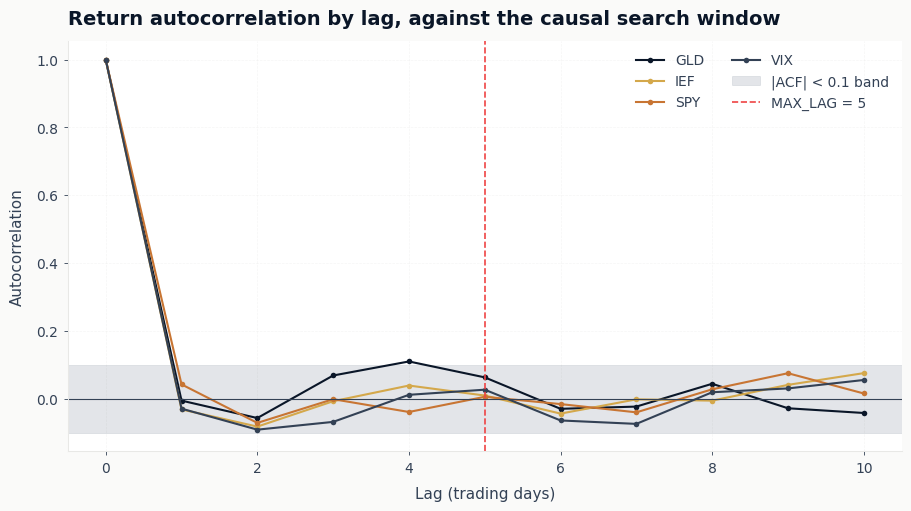

In [7]:
_lags = np.arange(len(next(iter(acf_results.values()))))
_series_colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["neutral"]]

fig, ax = plt.subplots(figsize=(9, 5))
for (var, acf), color in zip(acf_results.items(), _series_colors):
    ax.plot(_lags, acf, marker="o", markersize=4, linewidth=1.5, color=color, label=var)
ax.axhspan(-0.1, 0.1, color=COLORS["slate"], alpha=0.12, label="|ACF| < 0.1 band")
ax.axhline(0, color=COLORS["neutral"], linestyle="-", linewidth=0.8)
ax.axvline(
    MAX_LAG, color=COLORS["negative"], linestyle="--", linewidth=1.2, label=f"MAX_LAG = {MAX_LAG}"
)
ax.set_xlabel("Lag (trading days)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Return autocorrelation by lag, against the causal search window")
ax.legend(loc="upper right", frameon=False, ncol=2)
show_with_alt(
    fig,
    "Line chart of autocorrelation against lag in trading days, one line per series, with a "
    "marker at each lag. A shaded horizontal band marks the region where the absolute "
    "autocorrelation is below one tenth, a horizontal line marks zero, and a dashed vertical "
    "line marks the maximum lag the causal search uses. Every series starts at one by "
    "definition at lag zero and drops inside the band by the first lag, where they all stay.",
)

## 3. Prepare Data for Tigramite

In [8]:
# Convert to Tigramite format
data_array = returns.values
dataframe = pp.DataFrame(data_array, var_names=var_names)

try:
    shape = dataframe.values.shape if hasattr(dataframe.values, "shape") else data_array.shape
except Exception:
    shape = data_array.shape
print(f"Tigramite dataframe shape: {shape}")
print(f"Variable names: {dataframe.var_names}")

Tigramite dataframe shape: (500, 4)
Variable names: ['GLD', 'IEF', 'SPY', 'VIX']


## 4. PCMCI with Explicit False-Discovery-Rate Control

`pc_alpha=None` asks Tigramite to select the PC1 regularization parameter.
`fdr_method="fdr_bh"` then adjusts the final MCI p-values across the tested
links. The returned `p_matrix` therefore contains BH-adjusted p-values.

In [9]:
# Initialize PCMCI with partial correlation test
parcorr = ParCorr(significance="analytic")
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=1)

print("\nRunning PCMCI algorithm...")
print(f"Max lag: {MAX_LAG}")
print(f"Alpha level: {ALPHA_LEVEL}")
print("Multiple-testing policy: Benjamini-Hochberg FDR correction")

results = pcmci.run_pcmci(
    tau_max=MAX_LAG,
    pc_alpha=None,
    alpha_level=ALPHA_LEVEL,
    fdr_method="fdr_bh",
)

print("\nPCMCI completed!")


Running PCMCI algorithm...
Max lag: 5
Alpha level: 0.05
Multiple-testing policy: Benjamini-Hochberg FDR correction

##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
max_conds_dim = None
max_combinations = 1





## Resulting lagged parent (super)sets:

    Variable GLD has 5 link(s):
    [pc_alpha = 0.2]
        (GLD -4): max_pval = 0.07885, |min_val| =  0.080
        (IEF -2): max_pval = 0.13560, |min_val| =  0.068
        (GLD -3): max_pval = 0.13641, |min_val| =  0.067
        (GLD -5): max_pval = 0.15358, |min_val| =  0.065
        (IEF -1): max_pval = 0.17835, |min_val| =  0.061

    Variable IEF has 1 link(s):
    [pc_alpha = 0.1]
        (IEF -2): max_pval = 0.08614, |min_val| =  0.078

    Variable SPY has 1 link(s):
    [pc_alpha = 0.05]
        (SPY -2): max_pval = 0.04177, |min_val| =  0.092

    Variable VIX has 5 link(s):
    [pc_alpha = 0.4]
        (IEF -1): max_pval = 0.07995, |min_val| =  0.079
        (VIX -3): max_pval = 0.21656, |min_val| =  0.056
        (IEF -3): max_pval = 0.27148, |min_val| =  0.050
        (IEF -5): max_pval = 0.29040, |min_val| =  0.048
        (VIX -2): max_pval = 0.38615, |min_val| =  0.039

##
## Step 2: MCI algorithm
##

Parameters:

independence

## 5. Interpret Discovered Causal Graph

We threshold Tigramite's BH-adjusted MCI p-values at `ALPHA_LEVEL`.

In [10]:
p_matrix = results["p_matrix"]

print("\n" + "=" * 60)
print("DISCOVERED CAUSAL LINKS (PCMCI, BH-FDR adjusted)")
print("=" * 60)

significant_links = []
n_vars = len(var_names)

# Tigramite matrix indexing: p_matrix[source, target, lag]
# p_matrix[i, j, tau] tests: does source i at lag tau cause target j?
for i in range(n_vars):  # source variable
    for j in range(n_vars):  # target variable
        for tau in range(1, MAX_LAG + 1):
            if p_matrix[i, j, tau] < ALPHA_LEVEL:
                val = results["val_matrix"][i, j, tau]
                link = {
                    "from": var_names[i],
                    "to": var_names[j],
                    "lag": tau,
                    "strength": val,
                    "p_value": p_matrix[i, j, tau],
                }
                significant_links.append(link)
                print(
                    f"{var_names[i]}[t-{tau}] -> {var_names[j]}[t]  "
                    f"(strength={val:.3f}, p={p_matrix[i, j, tau]:.4f})"
                )

if not significant_links:
    print(f"No significant LAGGED causal links found at alpha = {ALPHA_LEVEL}")
else:
    print(f"\nTotal significant links: {len(significant_links)}")


DISCOVERED CAUSAL LINKS (PCMCI, BH-FDR adjusted)
No significant LAGGED causal links found at alpha = 0.05


## 6. Bootstrap Stability Analysis

Discovered edges may be unstable. We use block bootstrap to assess which
edges are consistently found across resamples. This is essential for
robustness in financial applications.

In [11]:
LAG_CONTEXT = 2 * MAX_LAG  # tigramite's per-dataset cut; see the docstring below


def block_bootstrap_blocks(values, block_size, rng, context=LAG_CONTEXT):
    """Draw blocks with replacement, stacked as separate datasets with lag context.

    The blocks are returned as an array of shape (blocks, context + block_size, variables)
    rather than concatenated into one series. Concatenating them would put the last row of
    one block next to the first row of another, and every lagged test PCMCI runs would then
    read that adjacency as time: with a block of twenty and a maximum lag of five, a quarter
    of the lagged pairs at each seam join rows that are not consecutive. Those pairs carry no
    dependence, so the contamination biases every edge toward the null - the same direction
    as the conclusion the chart is used to draw. Passed as separate datasets to
    `analysis_mode="multiple"`, tigramite pools the blocks without ever forming a pair across
    two of them.

    Each dataset carries `context` rows of real history before its block. Without them
    tigramite's `2 * tau_max` cut takes the first ten rows of every twenty-row block at the
    defaults here, half of it, and the resample runs on 250 usable observations against the
    490 of the fit whose stability it is measuring - which also reads as instability on the
    chart.
    """
    n = len(values)
    n_blocks = n // block_size
    starts = rng.integers(context, n - block_size + 1, size=n_blocks)
    return np.stack([values[start - context : start + block_size] for start in starts])


print(f"\nBootstrap stability analysis (n={N_BOOTSTRAP}, block_size={BLOCK_SIZE})...")

boot_rng = np.random.default_rng(SEED)
edge_counts = defaultdict(int)
for b in range(N_BOOTSTRAP):
    boot_blocks = block_bootstrap_blocks(returns.values, BLOCK_SIZE, boot_rng)
    boot_df = pp.DataFrame(boot_blocks, var_names=var_names, analysis_mode="multiple")
    boot_pcmci = PCMCI(
        dataframe=boot_df, cond_ind_test=ParCorr(significance="analytic"), verbosity=0
    )

    boot_results = boot_pcmci.run_pcmci(
        tau_max=MAX_LAG,
        pc_alpha=None,
        alpha_level=ALPHA_LEVEL,
        fdr_method="fdr_bh",
    )
    for i in range(n_vars):
        for j in range(n_vars):
            for tau in range(1, MAX_LAG + 1):
                if boot_results["p_matrix"][i, j, tau] < ALPHA_LEVEL:
                    edge_counts[(var_names[i], var_names[j], tau)] += 1

    if (b + 1) % 20 == 0:
        print(f"  Completed {b + 1}/{N_BOOTSTRAP} bootstraps...")


Bootstrap stability analysis (n=100, block_size=20)...


  Completed 20/100 bootstraps...


  Completed 40/100 bootstraps...


  Completed 60/100 bootstraps...


  Completed 80/100 bootstraps...


  Completed 100/100 bootstraps...


In [12]:
# Report edge stability
edge_stability = {edge: count / N_BOOTSTRAP for edge, count in edge_counts.items()}

print(f"\n--- Edge Stability (threshold: {STABILITY_THRESHOLD:.0%}) ---\n")
stable_edges = []
for edge, stability in sorted(edge_stability.items(), key=lambda x: -x[1]):
    source, target, lag = edge
    status = "STABLE" if stability >= STABILITY_THRESHOLD else "unstable"
    print(f"{source}[t-{lag}] -> {target}[t]: {stability:.0%} ({status})")
    if stability >= STABILITY_THRESHOLD:
        stable_edges.append(edge)

print(f"\nTotal edges: {len(edge_stability)}, Stable: {len(stable_edges)}")


--- Edge Stability (threshold: 50%) ---

GLD[t-4] -> GLD[t]: 29% (unstable)
IEF[t-3] -> VIX[t]: 25% (unstable)
VIX[t-2] -> VIX[t]: 25% (unstable)
VIX[t-3] -> VIX[t]: 20% (unstable)
IEF[t-3] -> SPY[t]: 20% (unstable)
IEF[t-2] -> IEF[t]: 20% (unstable)
IEF[t-2] -> VIX[t]: 18% (unstable)
IEF[t-5] -> VIX[t]: 15% (unstable)
IEF[t-1] -> VIX[t]: 14% (unstable)
GLD[t-5] -> GLD[t]: 11% (unstable)
IEF[t-2] -> SPY[t]: 10% (unstable)
VIX[t-5] -> SPY[t]: 9% (unstable)
IEF[t-5] -> SPY[t]: 9% (unstable)
SPY[t-4] -> SPY[t]: 9% (unstable)
GLD[t-3] -> GLD[t]: 9% (unstable)
SPY[t-2] -> SPY[t]: 9% (unstable)
IEF[t-1] -> IEF[t]: 8% (unstable)
VIX[t-1] -> VIX[t]: 8% (unstable)
IEF[t-4] -> SPY[t]: 7% (unstable)
SPY[t-2] -> VIX[t]: 6% (unstable)
SPY[t-3] -> IEF[t]: 6% (unstable)
GLD[t-2] -> IEF[t]: 6% (unstable)
VIX[t-4] -> IEF[t]: 6% (unstable)
SPY[t-5] -> SPY[t]: 6% (unstable)
IEF[t-2] -> GLD[t]: 5% (unstable)
VIX[t-2] -> SPY[t]: 5% (unstable)
SPY[t-5] -> VIX[t]: 4% (unstable)
SPY[t-3] -> VIX[t]: 4% (unsta

The stability chart is what turns a single PCMCI fit into a statement about the sample.
Each bar is the share of block-bootstrap resamples that recovered that edge, and the dashed
line is the threshold `STABILITY_THRESHOLD` sets. An edge the point estimate found but the
resamples rarely recover is a property of this particular sample; an edge recovered in most
of them survived being asked the question again.

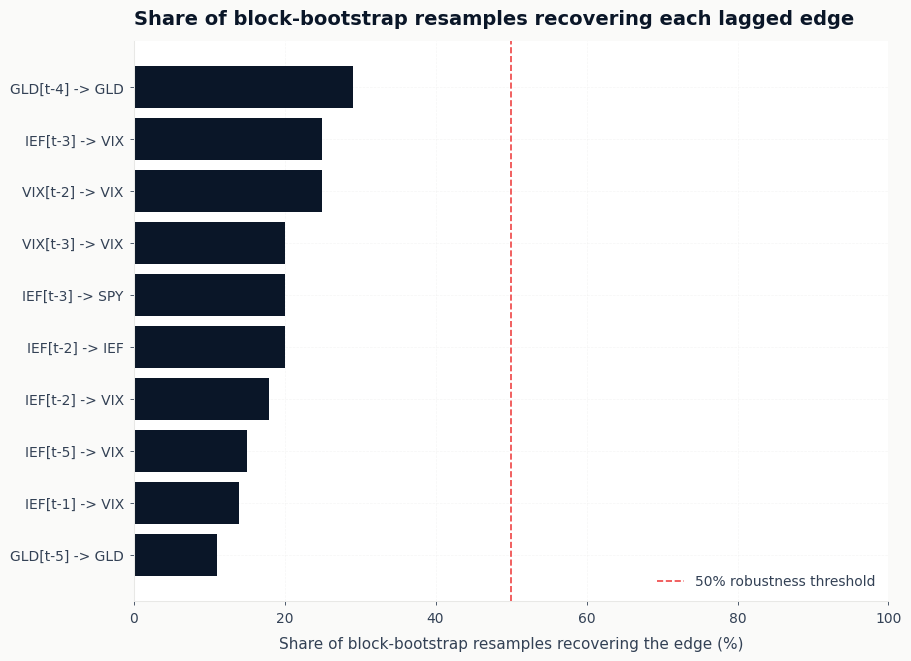

In [13]:
if edge_stability:
    _ranked = sorted(edge_stability.items(), key=lambda kv: kv[1], reverse=True)[:10]
    _labels = [f"{s}[t-{lag}] -> {t}" for (s, t, lag), _ in _ranked]
    _freqs = [v * 100 for _, v in _ranked]
    _bar_colors = [
        COLORS["amber"] if f >= STABILITY_THRESHOLD * 100 else COLORS["blue"] for f in _freqs
    ]

    fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(_ranked) + 1.5)))
    ypos = np.arange(len(_ranked))
    ax.barh(ypos, _freqs, color=_bar_colors)
    ax.axvline(
        STABILITY_THRESHOLD * 100,
        color=COLORS["negative"],
        linestyle="--",
        linewidth=1.2,
        label=f"{STABILITY_THRESHOLD:.0%} robustness threshold",
    )
    ax.set_yticks(ypos)
    ax.set_yticklabels(_labels)
    ax.invert_yaxis()
    ax.set_xlabel("Share of block-bootstrap resamples recovering the edge (%)")
    ax.set_xlim(0, 100)
    ax.set_title("Share of block-bootstrap resamples recovering each lagged edge")
    ax.legend(loc="lower right", frameon=False)
    show_with_alt(
        fig,
        "Horizontal bar chart of the ten lagged edges most often recovered, most frequent at "
        "the top, each bar the share of block-bootstrap resamples that found it on an axis "
        "running from zero to one hundred percent. A dashed vertical line marks the "
        "robustness threshold, and a bar reaching it is drawn in amber against blue for the "
        "rest.",
    )
else:
    print("No edges recovered in any bootstrap resample - the null is unanimous.")

## 7. Balanced Interpretation of Null Results

If no significant lagged links are found, this does NOT prove market efficiency.

In [14]:
print("\n" + "=" * 60)
print("INTERPRETATION OF RESULTS")
print("=" * 60)

if len(significant_links) == 0:
    explanations = [
        "Market efficiency could remove lagged predictability, but this is not proof.",
        "Power may be insufficient: daily returns are noisy and weak links need longer samples.",
        "Effects may exist at intraday horizons and vanish in daily aggregation.",
        "Linear ParCorr may miss nonlinear or state-dependent relationships.",
        "Structural breaks may require rolling or regime-conditional analysis.",
    ]
    print("No significant lagged causal links detected at alpha=0.05.")
    print("\nPossible interpretations:")
    for i, item in enumerate(explanations, 1):
        print(f"  {i}. {item}")
    print("\nRecommendation: run lag, frequency, and sample-window sensitivity checks.")
else:
    print(f"Found {len(significant_links)} significant lagged links.")
    print(f"Stable across bootstraps: {len(stable_edges)}")
    print("Stable edges are higher-priority hypotheses for out-of-sample validation.")
    print("Unstable edges are weak evidence and should not drive trading decisions.")


INTERPRETATION OF RESULTS
No significant lagged causal links detected at alpha=0.05.

Possible interpretations:
  1. Market efficiency could remove lagged predictability, but this is not proof.
  2. Power may be insufficient: daily returns are noisy and weak links need longer samples.
  3. Effects may exist at intraday horizons and vanish in daily aggregation.
  4. Linear ParCorr may miss nonlinear or state-dependent relationships.
  5. Structural breaks may require rolling or regime-conditional analysis.

Recommendation: run lag, frequency, and sample-window sensitivity checks.


## 8. Comparison with Granger Causality

**Granger causality limitations**:
1. Pairwise only - ignores multivariate confounding
2. Assumes linearity
3. Sensitive to lag selection
4. Can find spurious relationships due to common causes

**PCMCI advantages**:
1. Multivariate - conditions on all other variables
2. Conditions on selected observed parents under causal-sufficiency assumptions
3. Tests at multiple lags simultaneously
4. Explicit FDR control for the multivariate MCI tests

PCMCI can reduce bias from observed common drivers included in the panel. It
cannot eliminate hidden confounding, so discovered links remain hypotheses.

In [15]:
from scipy import stats as sp_stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.stats.multitest import multipletests


def simple_granger_test(X, Y, max_lag=5):
    """Pairwise Granger F test of X on Y at each lag order, with its p-value."""
    n = len(X)
    results = []

    for lag in range(1, max_lag + 1):
        # Restricted model: Y_t ~ Y_{t-1}, ..., Y_{t-lag}
        Y_lags = np.column_stack([Y[lag - i - 1 : n - i - 1] for i in range(lag)])
        Y_target = Y[lag:]

        model_r = LinearRegression().fit(Y_lags, Y_target)
        mse_r = mean_squared_error(Y_target, model_r.predict(Y_lags))

        # Unrestricted model: Y_t ~ Y_{t-1}, ..., Y_{t-lag}, X_{t-1}, ..., X_{t-lag}
        X_lags = np.column_stack([X[lag - i - 1 : n - i - 1] for i in range(lag)])
        XY_lags = np.column_stack([Y_lags, X_lags])

        model_u = LinearRegression().fit(XY_lags, Y_target)
        mse_u = mean_squared_error(Y_target, model_u.predict(XY_lags))

        df_denom = n - 3 * lag - 1
        f_stat = (mse_r - mse_u) / mse_u * df_denom / lag
        results.append(
            {
                "lag": lag,
                "f_stat": f_stat,
                "p_value": float(sp_stats.f.sf(f_stat, lag, df_denom)),
                "mse_reduction": (mse_r - mse_u) / mse_r,
            }
        )

    return results

Every pair and every lag order is a separate test, so the comparison is only fair if the
Granger side is corrected the way the PCMCI side is. The F statistics below carry their own
p-values, and Benjamini-Hochberg is applied across the whole set at once. Reporting the
largest F over the lag orders without a correction is the lag-selection sensitivity this
section lists as a Granger weakness, performed rather than described.

In [16]:
print("\n" + "=" * 60)
print("GRANGER CAUSALITY (PAIRWISE) COMPARISON")
print("=" * 60)
print("Granger is pairwise: it conditions on the target's own past and on nothing else.")

pairs_to_test = [("SPY", "IEF"), ("IEF", "VIX"), ("SPY", "VIX")]

granger_rows = []
for x_name, y_name in pairs_to_test:
    if x_name in returns.columns and y_name in returns.columns:
        for row in simple_granger_test(
            returns[x_name].values, returns[y_name].values, max_lag=GRANGER_MAX_LAG
        ):
            granger_rows.append({"from": x_name, "to": y_name, **row})

if granger_rows:
    granger_df = pd.DataFrame(granger_rows)
    granger_df["p_adj_bh"] = multipletests(granger_df["p_value"], method="fdr_bh")[1]
    granger_df["reject_at_alpha"] = granger_df["p_adj_bh"] < ALPHA_LEVEL
    display(
        granger_df[["from", "to", "lag", "f_stat", "p_value", "p_adj_bh", "reject_at_alpha"]].round(
            4
        )
    )
    print(
        f"{int(granger_df['reject_at_alpha'].sum())} of {len(granger_df)} pairwise "
        f"lag-order tests survive BH correction at alpha = {ALPHA_LEVEL}."
    )


GRANGER CAUSALITY (PAIRWISE) COMPARISON
Granger is pairwise: it conditions on the target's own past and on nothing else.


,from,to,lag,f_stat,p_value,p_adj_bh,reject_at_alpha
0,SPY,IEF,1,2.3419,0.1266,0.2244,False
1,SPY,IEF,2,1.7519,0.1745,0.2244,False
2,SPY,IEF,3,1.6649,0.1737,0.2244,False
3,IEF,VIX,1,3.1930,0.0746,0.2244,False
4,IEF,VIX,2,2.3466,0.0968,0.2244,False
5,IEF,VIX,3,2.8950,0.0348,0.2244,False
6,SPY,VIX,1,1.9049,0.1682,0.2244,False
7,SPY,VIX,2,1.3537,0.2592,0.2916,False
8,SPY,VIX,3,0.8183,0.4842,0.4842,False


0 of 9 pairwise lag-order tests survive BH correction at alpha = 0.05.


## 9. Results Summary

In [17]:
print("\n" + "=" * 60)
print("CHAPTER 15 NOTEBOOK RESULTS: 07_tigramite_time_series.py")
print("=" * 60)

results_summary = {
    "n_samples": len(returns),
    "n_variables": len(var_names),
    "variable_names": var_names,
    "max_lag_tested": MAX_LAG,
    "alpha_level": ALPHA_LEVEL,
    "n_bootstrap": N_BOOTSTRAP,
    "stability_threshold": STABILITY_THRESHOLD,
}

results_summary["n_significant_links"] = len(significant_links)
results_summary["n_stable_edges"] = len(stable_edges)
results_summary["stable_edges"] = [f"{e[0]}[t-{e[2]}]->{e[1]}" for e in stable_edges]

for key, value in results_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    elif isinstance(value, list) and len(value) > 3:
        print(f"{key}: [{len(value)} items]")
    else:
        print(f"{key}: {value}")


CHAPTER 15 NOTEBOOK RESULTS: 07_tigramite_time_series.py
n_samples: 500
n_variables: 4
variable_names: [4 items]
max_lag_tested: 5
alpha_level: 0.0500
n_bootstrap: 100
stability_threshold: 0.5000
n_significant_links: 0
n_stable_edges: 0
stable_edges: []


## Key Takeaways

### What the Evidence Supports

1. **Explicit Multiplicity Control**: Let Tigramite tune `pc_alpha` for parent
   selection, then use BH-FDR-adjusted MCI p-values for discovery.

2. **Predeclared Causal Horizon**: Test five trading days based on the weekly
   response window; use the ACF only to describe serial dependence.

3. **Bootstrap Stability**: an edge recovered in a majority of block-bootstrap resamples
   is the one worth reporting; `STABILITY_THRESHOLD` sets where the majority starts.

4. **Balanced Interpretation**: Null results have multiple possible explanations,
   not just "market efficiency".

### Practical Interpretation

- Granger tests pairs, while PCMCI conditions on selected variables from the panel.
- Bootstrap stability separates recurring edges from sample-specific discoveries.
- Discovered structure is statistical evidence, not proof of causality.
- A null result is compatible with low power, aggregation, nonlinearity, or regime change.